Analyzing Spotify Music Genres Using Python
Nathan Cao
6/26/2026


Introduction

The goal of this project is to compare Spotify music genres according to their audio characteristics. 
By analyzing variables such as popularity, danceability, energy, valence, tempo, loudness, and song duration, 
I will identify the characteristics that distinguish different genres and determine how genres differ from one another.

Here I am importing and loading the database.

In [38]:
import pandas as pd
import matplotlib.pyplot as plt

spotify = pd.read_csv(r"C:\Users\natha\OneDrive\Documents\dataset.csv")

spotify.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


Here I am examining the structure of the database to understand the variables, data types, and summary statistics. 

In [39]:
spotify.info()

spotify.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          11

,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,56999.500000,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,32909.109681,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28499.750000,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,56999.500000,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,85499.250000,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,113999.000000,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


Here I am cleaning the data, preparing it for analysis. I wanted to check for missing values to see if it would affect the analysis. Then I wanted to remove any duplicate data to prevent them from influencing the results. Then I created a new variable to convert the songs from milliseconds to minutes because that is typically how we view the length of songs. 

In [40]:
spotify.isnull().sum()

spotify.duplicated().sum()

spotify = spotify.drop_duplicates()

spotify["duration_min"] = spotify["duration_ms"] / 60000

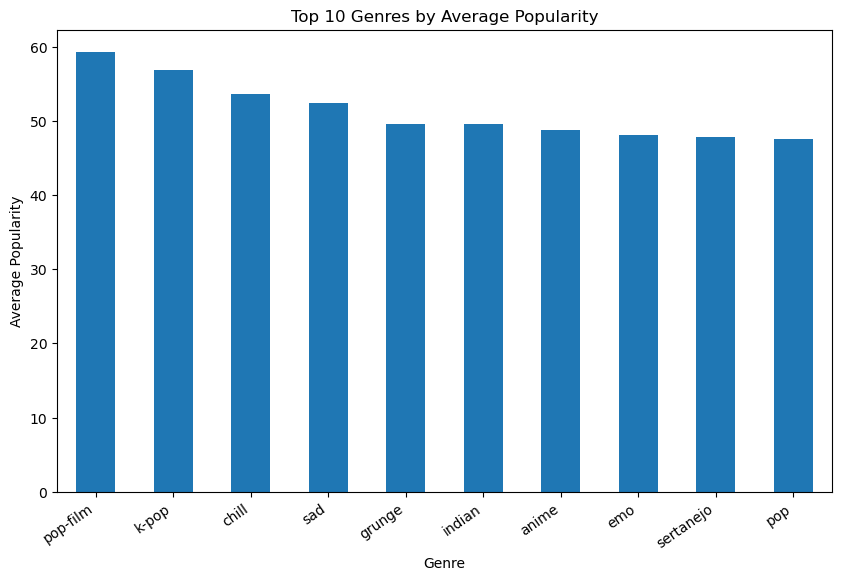

In [41]:
genrePopularity = spotify.groupby("track_genre")["popularity"] \
                         .mean() \
                         .sort_values(ascending=False) \
                         .head(10)

plt.figure(figsize=(10,6))
genrePopularity.plot(kind="bar")
plt.title("Top 10 Genres by Average Popularity")
plt.xlabel("Genre")
plt.ylabel("Average Popularity")
plt.xticks(rotation=35, ha="right")
plt.show()

Here is a graph showing the top 10 genres by average popularity. As we can see, pop film was the most popular.

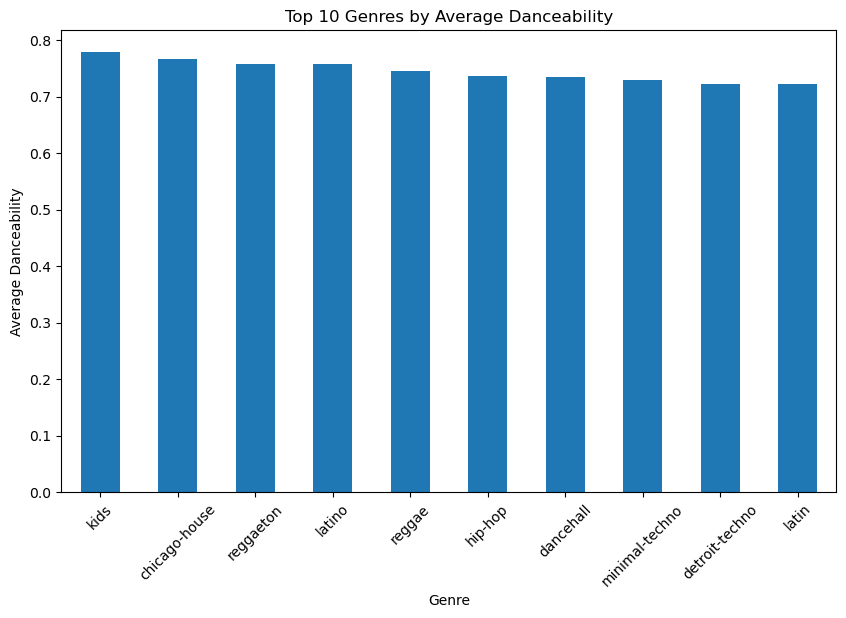

In [42]:
genreDance = spotify.groupby("track_genre")["danceability"].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
genreDance.plot(kind="bar")
plt.title("Top 10 Genres by Average Danceability")
plt.xlabel("Genre")
plt.ylabel("Average Danceability")
plt.xticks(rotation=45)
plt.show()

For genres that are the most danceable. We can see that kids scored the highest. The top 10 genres are relatively close. But what they have in common is that they have steady beats. A lot of the genres in the top 10 are closely related or sub-genres of EDM as well.

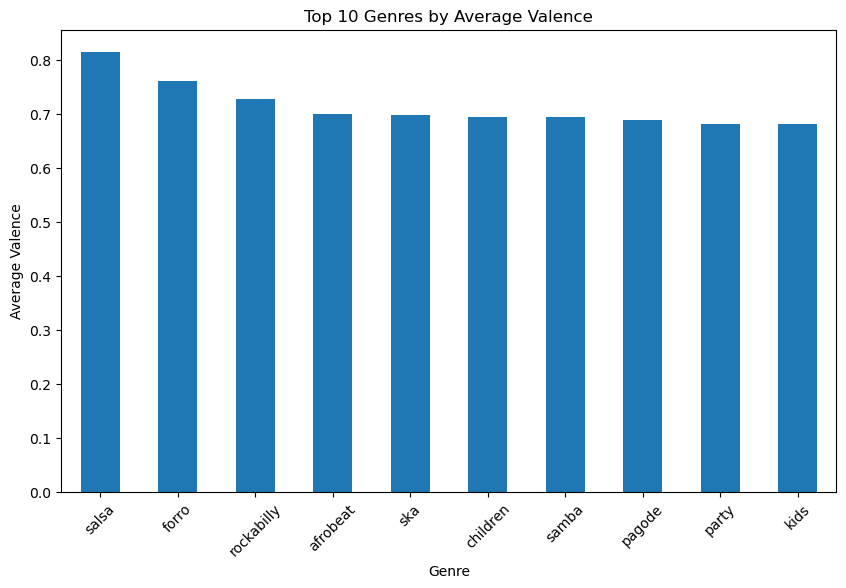

In [43]:
genreValence = spotify.groupby("track_genre")["valence"].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
genreValence.plot(kind="bar")
plt.title("Top 10 Genres by Average Valence")
plt.xlabel("Genre")
plt.ylabel("Average Valence")
plt.xticks(rotation=45)
plt.show()

This graph shows the average valence or brightness in the music genres. Salsa has the highest average likely due to its happiness and energeticness. 

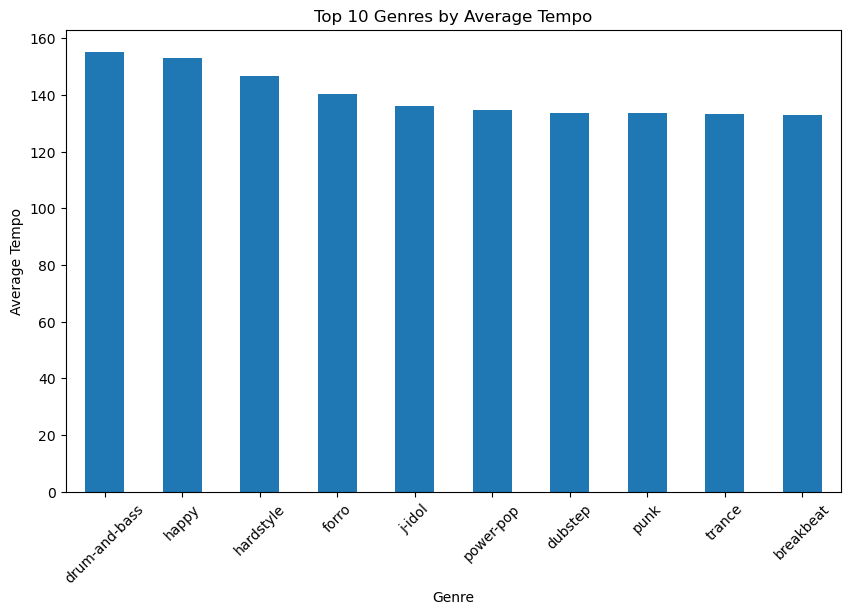

In [44]:
genreTempo = spotify.groupby("track_genre")["tempo"].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
genreTempo.plot(kind="bar")
plt.title("Top 10 Genres by Average Tempo")
plt.xlabel("Genre")
plt.ylabel("Average Tempo")
plt.xticks(rotation=45)
plt.show()

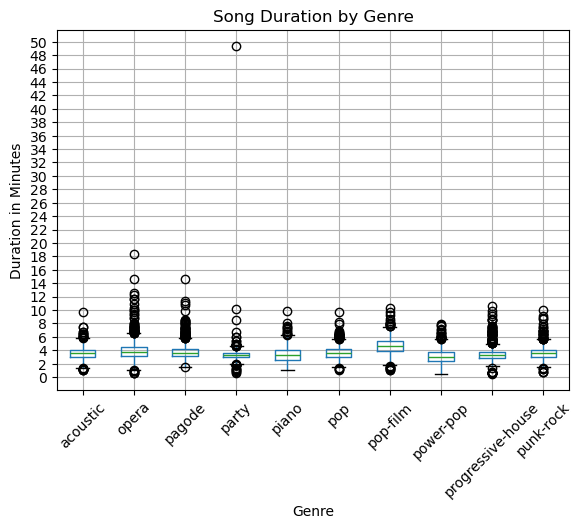

In [45]:
spotifyTopGenres.boxplot(column="duration_min", by="track_genre")

plt.title("Song Duration by Genre")
plt.suptitle("")
plt.xlabel("Genre")
plt.ylabel("Duration in Minutes")

plt.xticks(rotation=45)
plt.yticks(range(0, 52, 2))   # Change increments here

plt.show()

This boxplot graph compares the genres by duration. The median duration is between 3 and 4 minutes. This means that the duration of the music is consistent regardless of the genre. 

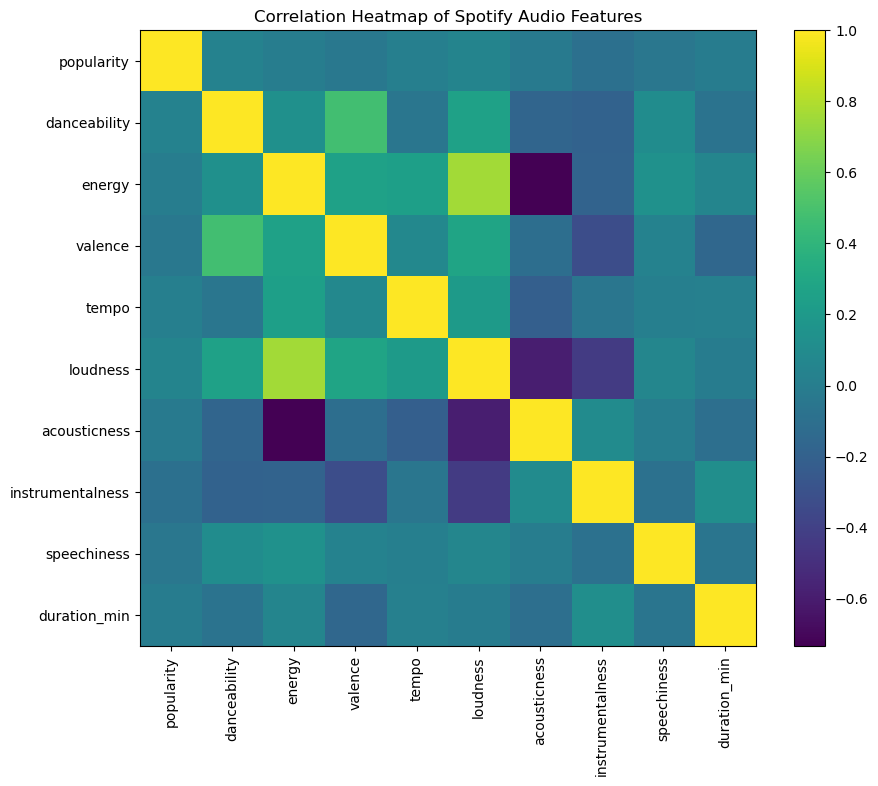

In [46]:
audioFeatures = [
    "popularity",
    "danceability",
    "energy",
    "valence",
    "tempo",
    "loudness",
    "acousticness",
    "instrumentalness",
    "speechiness",
    "duration_min"
]

corr = spotify[audioFeatures].corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(audioFeatures)), audioFeatures, rotation=90)
plt.yticks(range(len(audioFeatures)), audioFeatures)
plt.title("Correlation Heatmap of Spotify Audio Features")
plt.show()

This heatmap shows the correlation between different spotify audio features. The closer to 1 indicates a strong positive relation and viseversa for -1. If the value is close to 0, there is no correlation. 

In [47]:
genreProfile = spotify.groupby("track_genre")[
    ["popularity", "danceability", "energy", "valence", "tempo", "duration_min"]
].mean().round(2)

genreProfile.head(10)

,popularity,danceability,energy,valence,tempo,duration_min
track_genre,,,,,,
acoustic,42.48,0.55,0.44,0.42,119.01,3.58
afrobeat,24.40,0.67,0.70,0.70,119.21,4.14
alt-rock,33.94,0.53,0.75,0.52,124.63,3.92
alternative,24.34,0.56,0.72,0.50,122.23,3.70
ambient,44.19,0.37,0.24,0.17,111.11,3.95
anime,48.77,0.54,0.67,0.43,123.53,3.50
black-metal,22.45,0.30,0.87,0.19,128.60,5.19
bluegrass,25.68,0.53,0.53,0.64,126.58,3.69
blues,31.19,0.57,0.58,0.60,116.57,3.71


The table above shows the average audio characteristics for each Spotify music genre. Each row represents a genre, and each column displays the average value of a particular audio feature.

Spotify music genres were analyzed using several audio features of the song, including popularity, danceability, energy, valence, tempo, and duration. The analysis revealed significant differences in musical characteristics across genres. Some genres are more upbeat and have a faster tempo, whereas others are more relaxed, acoustic, or danceable. Additionally, the correlation analysis showed that some features, such as energy and loudness, are strongly correlated, while popularity is weakly correlated with the majority of audio features. Finally, the project demonstrates how to use Python data analysis to identify musical patterns and compare genres based on measurable audio characteristics.

Sorce: http://kaggle.com/datasets/maharshipandya/-spotify-tracks-dataset

This is the database I used for this project. 